In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.utils import shuffle
from scipy.stats import ks_2samp

In [2]:
#STD_DIR = "Dataset_Preparation\STD_images_train"      # <-- set path to standard images folder
STD_DIR = "Dataset_Preparation\STD_images_train"
AMBE_DIR = "Dataset_Preparation\AmBe_images_train"    # <-- set path to AmBe images folder

IMG_SIZE = (128, 128)
VALIDATION_SPLIT = 0.2
SEED = 4267
BATCH_SIZE = 64


# Reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
def load_all_images(folder, img_size=(128,128)):
    """Load grayscale images from folder, normalize to [0,1], skip corrupted."""
    exts = ['*.png', '*.PNG', '*.jpg', '*.jpeg', '*.bmp', '*.gif']
    paths = []
    
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
        
    # --- THE FIX ---
    # Convert to a set to remove duplicates, then back to a sorted list
    paths = sorted(list(set(paths)))
    
    imgs = []
    for p in paths:
        try:
            im = Image.open(p).convert("L")  # grayscale
            im = im.resize(img_size, Image.BILINEAR)
            arr = np.array(im, dtype=np.float32) / 255.0  # scale to [0,1]
            imgs.append(arr[..., None])  # add channel dim
        except Exception as e:
            print(f"[load_all_images] skipping {p}: {e}")
            
    if len(imgs) == 0:
        raise RuntimeError(f"No images loaded from {folder}")
        
    return np.stack(imgs, axis=0)  # (N,H,W,1)

def normalize_per_image(x):
    """Per-image mean/std normalization (avoid division by zero)."""
    mean = np.mean(x, axis=(1,2,3), keepdims=True)
    std = np.std(x, axis=(1,2,3), keepdims=True)
    return (x - mean) / (std + 1e-6)



def visualize_grid(images, titles=None, ncol=5, figsize=(12,3), cmap="gray"):
    n = len(images)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrow, ncol, i+1)
        plt.imshow(images[i].squeeze(), cmap=cmap, vmin=0, vmax=1)
        plt.axis("off")
        if titles:
            plt.title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()

Loading images...
Loaded 7375 standard images and 7362 AmBe images.
Sample standard images:


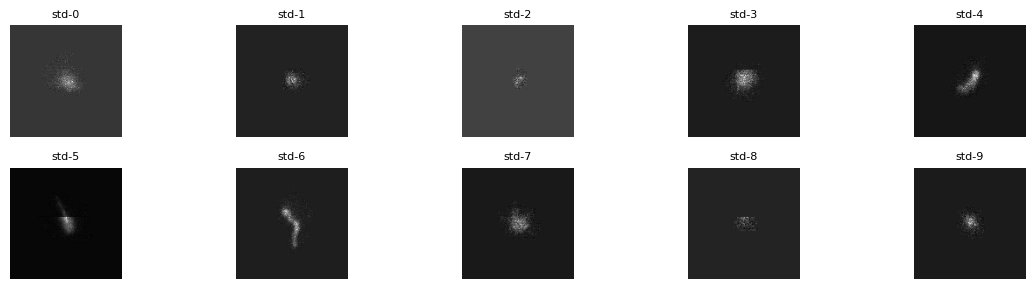

Sample AmBe images:


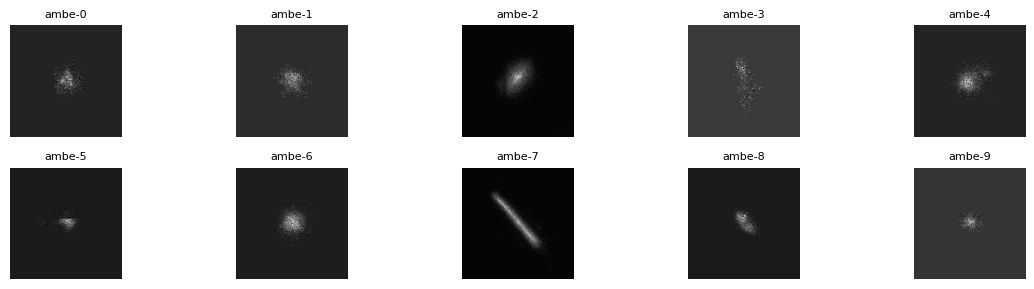

In [4]:
print("Loading images...") 
std_images = load_all_images(STD_DIR, img_size=IMG_SIZE)   # label 0
ambe_images = load_all_images(AMBE_DIR, img_size=IMG_SIZE) # label 1

print(f"Loaded {len(std_images)} standard images and {len(ambe_images)} AmBe images.")
print("Sample standard images:")
visualize_grid(std_images[:10], titles=[f"std-{i}" for i in range(10)], ncol=5)
print("Sample AmBe images:")
visualize_grid(ambe_images[:10], titles=[f"ambe-{i}" for i in range(10)], ncol=5)


In [5]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors


def estimate_pedestal(image):
    """
    Estimate pedestal from mode of pixel distribution.
    
    Logic: ~95% of image is background noise → forms the largest peak (mode).
    Signal pixels (~5%) are rare and above pedestal → don't affect mode.
    """
    # Global mode: most common value across entire image
    hist, edges = np.histogram(image, bins=256)
    mode_bin = np.argmax(hist)
    pedestal_value = (edges[mode_bin] + edges[mode_bin + 1]) / 2

    # Sigma: std dev of pixels near the pedestal (window around mode)
    window_width = 20  # ADC units around mode
    mask_pedestal = np.abs(image - pedestal_value) <= window_width
    pedestal_sigma = np.std(image[mask_pedestal])

    return pedestal_value, pedestal_sigma





def convert_numpy_image_to_graph(img_array, k=50, num_edges=10):
    """
    Converts an in-memory normalized grayscale image array into a K-NN graph.
    
    Parameters:
    - img_array: NumPy array of shape (H, W, 1) or (H, W) with values in [0, 1]
    - k: Number of spatial neighbors to connect for each node
    - tolerance_255: Background cutoff threshold defined on a 0-255 scale
    
    Returns:
    - x_tensor: PyTorch tensor of node features [Num_Nodes, 3] -> (x, y, intensity)
    - edge_index: PyTorch tensor of edge connections [2, Num_Edges]
    """
    # Squeeze out the channel dimension if it exists -> shape becomes (H, W)
    img_2d = img_array.squeeze()
    height, width = img_2d.shape

    # 1. Find the background level using the exact mode
    # We temporarily round to 3 decimal places to group close background values smoothly
    mode_val, sigma = estimate_pedestal(img_2d)
    
    # Convert the 0-255 tolerance parameter to the [0, 1] float scale
    threshold = mode_val +  sigma
    
    # 2. Extract signal pixels that survive the cut
    y_coords, x_coords = np.where(img_2d > threshold)
    intensities = img_2d[y_coords, x_coords]
    
    num_nodes = len(intensities)
    if num_nodes < k + 1:
        # Fallback case if an image is completely blank or threshold is too aggressive
        return None, None

    # 3. Construct Normalized Feature Matrix (X)
    x_norm = x_coords/128
    y_norm = y_coords/128
    # Intensities are already normalized to [0,1]
    
    nodes_features = np.column_stack((x_norm, y_norm, intensities))
    x_tensor = torch.tensor(nodes_features, dtype=torch.float32)

    # 4. Construct Spatial Edge Connections via K-NN
    spatial_coords = np.column_stack((x_coords, y_coords))
    
    knn = NearestNeighbors(n_neighbors=num_edges+1, algorithm='auto').fit(spatial_coords)
    _, indices = knn.kneighbors(spatial_coords)
    
    # Map every node to its k-nearest neighbors (skipping index 0 which is itself)
    source_nodes = np.repeat(np.arange(num_nodes), num_edges) 
    target_nodes = indices[:, 1:].flatten()
    
    edge_index_np = np.vstack((source_nodes, target_nodes))
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)

    return x_tensor, edge_index

In [6]:
def process_dataset(images_array, label_value, k=50):
    """
    Loops through the image array and converts each image into a graph dictionary.
    """
    processed_graphs = []
    skipped_count = 0
    
    for i in range(len(images_array)):
        # Extract features and topology for image 'i'
        x_tensor, edge_index = convert_numpy_image_to_graph(images_array[i], k=k)
        
        if x_tensor is not None:
            # Package into a dictionary format suitable for PyTorch DataLoaders
            graph_dict = {
                'X': x_tensor,
                'A': edge_index,
                'y': torch.tensor([[label_value]], dtype=torch.float32)
            }
            processed_graphs.append(graph_dict)
        else:
            skipped_count += 1
            
    if skipped_count > 0:
        print(f"Skipped {skipped_count} images (not enough active pixels).")
        
    return processed_graphs

# Apply to your loaded images
print("Extracting graphs from std_images...")
std_graphs = process_dataset(std_images, label_value=0, k=50)
ambe_graphs = process_dataset(ambe_images, label_value=1, k=50)

print(f"Successfully extracted {len(std_graphs)} graphs!")
print(f"Successfully extracted {len(ambe_graphs)} graphs!")

Extracting graphs from std_images...
Skipped 13 images (not enough active pixels).
Skipped 13 images (not enough active pixels).
Successfully extracted 7362 graphs!
Successfully extracted 7349 graphs!


KeyboardInterrupt: 

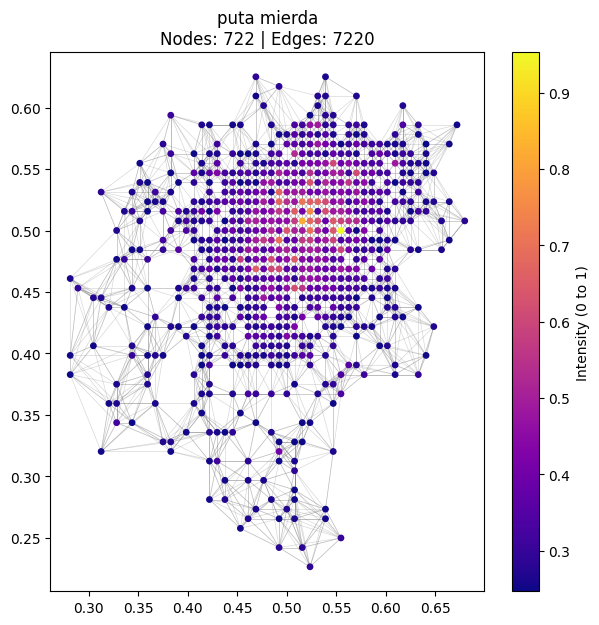

In [ ]:
def visualize_extracted_graph(graph_dict, title="Extracted Graph Validation"):
    """
    Plots the extracted nodes and edges using absolute pixel coordinates.
    """
    if graph_dict is None or 'X' not in graph_dict: 
        print("No graph data to visualize.")
        return
        
    nodes = graph_dict['X'].numpy()
    edges = graph_dict['A'].numpy()
    
    # Column 0 is X, Column 1 is Y, Column 2 is Intensity
    x_coords = nodes[:, 0]
    y_coords = nodes[:, 1] 
    intensities = nodes[:, 2]

    plt.figure(figsize=(7, 7))
    
    # 1. Draw the Edges (Connections)
    for i in range(edges.shape[1]):
        source_idx = edges[0, i]
        target_idx = edges[1, i]
        
        plt.plot(
            [x_coords[source_idx], x_coords[target_idx]],
            [y_coords[source_idx], y_coords[target_idx]],
            color='gray', alpha=0.3, linewidth=0.5, zorder=1
        )
        
    # 2. Draw the Nodes (Colored by pixel intensity)
    scatter = plt.scatter(
        x_coords, y_coords, 
        c=intensities, cmap='plasma', s=15, zorder=2
    )
    
    plt.colorbar(scatter, label="Intensity (0 to 1)")
    plt.title(f"{title}\nNodes: {len(x_coords)} | Edges: {edges.shape[1]}")
    
    # Set limits to your image size (128x128)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
    # Invert the Y-axis! Image matrices start with Y=0 at the TOP. 
    # Standard plots put Y=0 at the bottom. We invert to match the original image view.
    plt.gca().invert_yaxis()
    
    plt.axis('on') # Kept 'on' so you can see the 0-128 coordinate boundaries
    plt.show()

# --- Test it on the very first image in your processed list! ---
for i in range (0,len(std_graphs)):
    visualize_extracted_graph(std_graphs[i], title="puta mierda")


HERE STARTS THE ACTUALS GNN

In [11]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
import random
from torch_geometric.nn import BatchNorm
from torch_geometric.nn import global_max_pool

# ==========================================
# 1. CWoLa DATA PREPARATION
# ==========================================
# Assume you have already run your extraction function and have two lists of PyG Data objects.
# (If you currently have dictionaries, just convert them to PyG Data objects like below).

# Example of converting your extracted tensors into PyG Data objects:
# std_graphs = [Data(x=tensors[0], edge_index=tensors[1], y=torch.tensor([[0.0]])) for tensors in std_data]
# ambe_graphs = [Data(x=tensors[0], edge_index=tensors[1], y=torch.tensor([[1.0]])) for tensors in ambe_data]

# 1. Combine your extracted dictionaries (if you haven't already)
# Assume std_graphs and ambe_graphs are your lists of dictionaries
combined_dicts = std_graphs + ambe_graphs

# 2. CONVERT DICTIONARIES TO PyG DATA OBJECTS
pyg_dataset = []
for g_dict in combined_dicts:
    # We map your dictionary keys ('X', 'A') to the official PyG attributes ('x', 'edge_index')
    pyg_data = Data(
        x=g_dict['X'], 
        edge_index=g_dict['A'], 
        y=g_dict['y']
    )
    pyg_dataset.append(pyg_data)

# 3. Shuffle and Split
random.seed(42)
random.shuffle(pyg_dataset)

split_idx = int(len(pyg_dataset) * 0.8)
train_dataset = pyg_dataset[:split_idx]
test_dataset = pyg_dataset[split_idx:]

# 4. Create the Loaders
train_loader = PyGDataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = PyGDataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Successfully converted! Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

from torch_geometric.nn import BatchNorm # <--- IMPORT BATCHNORM

# ==========================================
# 1. THE STABILIZED GNN MODEL
# ==========================================
class CWolaGNN(torch.nn.Module):
    def __init__(self, num_node_features):
        super().__init__()
        
        # --- FASE 1: Estrazione Features (Simile alle Conv2D) ---
        self.conv1 = GCNConv(num_node_features, 32)
        self.bn1 = BatchNorm(32)
        
        self.conv2 = GCNConv(32, 64)
        self.bn2 = BatchNorm(64)
        
        # --- FASE 2: Il Classificatore (Simile ai tuoi strati Dense) ---
        # Aggiungiamo uno strato intermedio a 64 neuroni come nella CNN
        self.classifier_hidden = torch.nn.Linear(64, 64)
        
        # Aggiungiamo il Dropout al 50% come nella CNN
        self.dropout = torch.nn.Dropout(p=0.5)
        
        # Output finale (1 nodo per la classificazione binaria)
        self.classifier_out = torch.nn.Linear(64, 1)

    def forward(self, x, edge_index, batch):
        # Layer Convoluzionale 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer Convoluzionale 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        # --- IL POOLING GLOBALE ---
        # Usiamo il MAX pooling: estrae l'intensità e le coordinate massime
        # della traccia, ignorando i pixel di "rumore" deboli
        x = global_max_pool(x, batch)

        # --- LA FASE DI CLASSIFICAZIONE (Ispirata alla CNN) ---
        # 1. Strato nascosto + ReLU
        x = self.classifier_hidden(x)
        x = F.relu(x)
        
        # 2. Dropout (si attiva solo durante il model.train())
        x = self.dropout(x)
        
        # 3. Output finale
        out = self.classifier_out(x)

        return out

# ==========================================
# 2. THE BUG-FREE TRAINING LOOP
# ==========================================
model = CWolaGNN(num_node_features=3)

# Lower the learning rate! 1e-3 (0.001) or 5e-4 (0.0005) is much safer.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 
criterion = torch.nn.BCEWithLogitsLoss()

def train():
    model.train()
    total_loss = 0

    for data in train_loader:
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index, data.batch)
        
        # --- THE BROADCASTING FIX ---
        # .view(-1) forces both the outputs and labels to be strict 1D arrays 
        # so they line up 1-to-1 perfectly.
        loss = criterion(out.view(-1), data.y.view(-1))
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    return total_loss / len(train_loader.dataset)

def test():
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data in test_loader:
            out = model(data.x, data.edge_index, data.batch)
            
            probs = torch.sigmoid(out.view(-1)) # Also view(-1) here for safety
            predicted = (probs > 0.5).float()
            
            correct += (predicted == data.y.view(-1)).sum().item()
            total += data.num_graphs

    return correct / total

# --- Execution ---
print("Starting Stabilized CWoLa Training...")
for epoch in range(1, 31):
    loss = train()
    acc = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}')

Successfully converted! Train size: 11768, Test size: 2943
Starting Stabilized CWoLa Training...
Epoch: 001, Loss: 0.6965, Test Acc: 0.5348
Epoch: 002, Loss: 0.6908, Test Acc: 0.5117
Epoch: 003, Loss: 0.6878, Test Acc: 0.5291
Epoch: 004, Loss: 0.6859, Test Acc: 0.5243
Epoch: 005, Loss: 0.6852, Test Acc: 0.5291
Epoch: 006, Loss: 0.6837, Test Acc: 0.5297
Epoch: 007, Loss: 0.6851, Test Acc: 0.5294
Epoch: 008, Loss: 0.6851, Test Acc: 0.5233
Epoch: 009, Loss: 0.6837, Test Acc: 0.5498


KeyboardInterrupt: 